In [1]:
## 📦 Import basic libraries & info
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

RSEED = 42

## 🤖 Models & Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
#from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

## 🛠️ Tools & Optimizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

## 📊 Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

## 🎨 Plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import flight data
flights = pd.read_csv("data/Train_with_Countries.csv")

# Overview Columns
- DATOP - Date of flight
- fltid - Flight number
- DEPSTN - Departure point
- ARRSTN - Arrival point
- STD - Scheduled Time departure
- STA - Scheduled Time arrival
- STATUS - Flight status
    - ETD - Expected Time departure
    - ETA - Expected Time arrival
    - ATD - Actual Time of Departure
    - ATA - Actual Time of arrival
    - DELAY1 - Delay code 1
    - DUR1 - delay time 1
    - DELAY2 - Delay code 2
    - DUR2 - delay time 2
    - DELAY3 - Delay code 3
    - DUR3 - delay time 3
    - DELAY4 - Delay code 4
    - DUR4 - delay time 4
- AC - Aircraft Code

In [3]:
flights.head()

,ID,DATOP,FLTID,DEPSTN,DEP_COUNTRY,ARRSTN,ARR_COUNTRY,STD,STA,STATUS,AC,target
0,train_id_0,2016-01-03,TU 0712,CMN,Morocco,TUN,Tunisia,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0
1,train_id_1,2016-01-13,TU 0757,MXP,Italy,TUN,Tunisia,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0
2,train_id_2,2016-01-16,TU 0214,TUN,Tunisia,IST,Turkey,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0
3,train_id_3,2016-01-17,TU 0480,DJE,Tunisia,NTE,France,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0
4,train_id_4,2016-01-17,TU 0338,TUN,Tunisia,ALG,Algeria,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0


In [4]:
## Spalte für Origin-Destination Paar hinzugefügt
flights["OD"] = flights.DEPSTN + "_" + flights.ARRSTN

flights.head()

,ID,DATOP,FLTID,DEPSTN,DEP_COUNTRY,ARRSTN,ARR_COUNTRY,STD,STA,STATUS,AC,target,OD
0,train_id_0,2016-01-03,TU 0712,CMN,Morocco,TUN,Tunisia,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0,CMN_TUN
1,train_id_1,2016-01-13,TU 0757,MXP,Italy,TUN,Tunisia,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0,MXP_TUN
2,train_id_2,2016-01-16,TU 0214,TUN,Tunisia,IST,Turkey,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0,TUN_IST
3,train_id_3,2016-01-17,TU 0480,DJE,Tunisia,NTE,France,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0,DJE_NTE
4,train_id_4,2016-01-17,TU 0338,TUN,Tunisia,ALG,Algeria,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0,TUN_ALG


In [5]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107833 entries, 0 to 107832
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           107833 non-null  object 
 1   DATOP        107833 non-null  object 
 2   FLTID        107833 non-null  object 
 3   DEPSTN       107833 non-null  object 
 4   DEP_COUNTRY  107833 non-null  object 
 5   ARRSTN       107833 non-null  object 
 6   ARR_COUNTRY  107833 non-null  object 
 7   STD          107833 non-null  object 
 8   STA          107833 non-null  object 
 9   STATUS       107833 non-null  object 
 10  AC           107833 non-null  object 
 11  target       107833 non-null  float64
 12  OD           107833 non-null  object 
dtypes: float64(1), object(12)
memory usage: 10.7+ MB


In [6]:
# DATOP und STD direkt in datetime umwandeln
flights["DATOP"] = pd.to_datetime(flights["DATOP"], format="%Y-%m-%d", errors="coerce")
flights["STD"] = pd.to_datetime(flights["STD"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# STA enthält Uhrzeit mit Punkt statt Doppelpunkt – erst korrigieren, dann umwandeln
flights["STA_cleaned"] = flights["STA"].str.replace(".", ":", regex=False)
flights["STA"] = pd.to_datetime(flights["STA_cleaned"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Temporäre Hilfsspalte entfernen
flights.drop(columns=["STA_cleaned"], inplace=True)

In [7]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107833 entries, 0 to 107832
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   ID           107833 non-null  object        
 1   DATOP        107833 non-null  datetime64[ns]
 2   FLTID        107833 non-null  object        
 3   DEPSTN       107833 non-null  object        
 4   DEP_COUNTRY  107833 non-null  object        
 5   ARRSTN       107833 non-null  object        
 6   ARR_COUNTRY  107833 non-null  object        
 7   STD          107833 non-null  datetime64[ns]
 8   STA          107833 non-null  datetime64[ns]
 9   STATUS       107833 non-null  object        
 10  AC           107833 non-null  object        
 11  target       107833 non-null  float64       
 12  OD           107833 non-null  object        
dtypes: datetime64[ns](3), float64(1), object(9)
memory usage: 10.7+ MB


<Axes: xlabel='target', ylabel='Count'>

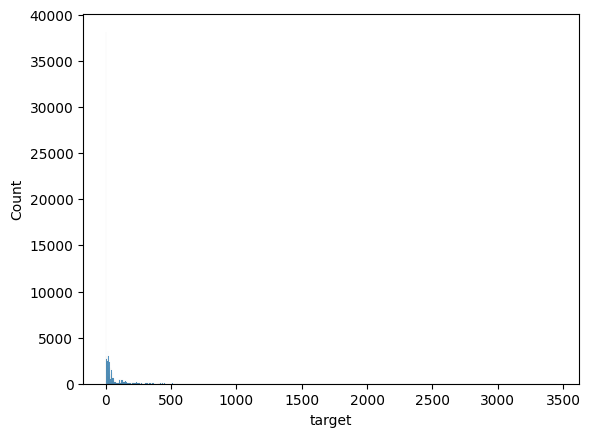

In [8]:
sns.histplot(flights, x="target")

In [9]:
flights.groupby("AC").target.mean().sort_values(ascending=False)

AC
OL 321ABY    205.400000
GJ 734CGC    167.705882
5K 345TFX    136.906542
GW 320MQH    126.147059
GJ 734MGC    121.693333
                ...    
TU CR9XXX      0.000000
UG AT7AT7      0.000000
UG CR9CR9      0.000000
UG CR9XXX      0.000000
TU 32A32A      0.000000
Name: target, Length: 68, dtype: float64

In [10]:
# Wochentag (0 = Montag, 6 = Sonntag)
flights["weekday"] = flights["DATOP"].dt.weekday

# Monat (1 = Januar, 12 = Dezember)
flights["month"] = flights["DATOP"].dt.month

# Abflugstunde (Stunde aus geplanter Abflugzeit)
flights["dep_hour"] = flights["STD"].dt.hour

# Ankunftsstunde (Stunde aus geplanter Ankunftszeit)
flights["arr_hour"] = flights["STA"].dt.hour

# Geplante Flugdauer in Minuten
flights["scheduled_duration_min"] = (flights["STA"] - flights["STD"]).dt.total_seconds() / 60


In [11]:
## Spaltennamen bereinigen
flights.columns = (
    flights.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

## Leerzeichen am Anfang und Ende innerhalb der Spalte fltid entfernt
flights["fltid"] = flights["fltid"].str.strip()

In [12]:
flights = flights.drop("id", axis = 1)
flights.head()

,datop,fltid,depstn,dep_country,arrstn,arr_country,std,sta,status,ac,target,od,weekday,month,dep_hour,arr_hour,scheduled_duration_min
0,2016-01-03,TU 0712,CMN,Morocco,TUN,Tunisia,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,TU 32AIMN,260.0,CMN_TUN,6,1,10,12,145.0
1,2016-01-13,TU 0757,MXP,Italy,TUN,Tunisia,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,TU 31BIMO,20.0,MXP_TUN,2,1,15,16,110.0
2,2016-01-16,TU 0214,TUN,Tunisia,IST,Turkey,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,TU 32AIMN,0.0,TUN_IST,5,1,4,6,155.0
3,2016-01-17,TU 0480,DJE,Tunisia,NTE,France,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,TU 736IOK,0.0,DJE_NTE,6,1,14,17,170.0
4,2016-01-17,TU 0338,TUN,Tunisia,ALG,Algeria,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,TU 320IMU,22.0,TUN_ALG,6,1,14,15,80.0


## Fltid mapping (Yannek)

#### fltid Bedeutung:
- 0000: Route planning, repositioning, cargo, maintenance, test, etc.
- 1-99: Premium oder Langstreckenflüge
- 0100-0999: Interkontinental oder wichtige Flüge
- 1000-1299: Kurzstrecke u. Inland
- 3000-5999: Regionalflüge oder Tochtergesellschaften
- 6000+: Codeshare (durch andere Airline ausgeführt)
- 8000: Charter
- 9000: Positionierungsflüge

In [13]:
### Code here

# Save unique Flight IDs to CSV-file
# pd.DataFrame(flights['fltid'].unique().tolist()).to_csv('./data/Unique_fltids.csv')

# Use regular expressions to extract string components from fltid column
# Note: Requires import re` to work
flights['airline'] = flights['fltid'].str.extract(r'([A-Z]{2,3})')
flights['flt_type'] = flights['fltid'].str.extract(r'([0-9]{4})')

# Recode FLT_TYPE from number to string descriptor using regular expressions
flt_type_conditions = [
    flights['flt_type'].str.match(r'(^00[0-9]{2})$'),           # Match 0001-0099 'premium/ long haul'
    flights['flt_type'].str.match(r'(^0[1-9][0-9]{2}$)'),       # Match 0100-0999 'intercontinental'
    flights['flt_type'].str.match(r'(^1[0-2][0-9][0-9])'),      # Match 1000-1299 'domestic/ short haul'
    flights['flt_type'].str.match(r'(^[3-5][0-9][0-9][0-9])'),  # Match 3000-5999 'regional/ subsidiary'
    flights['flt_type'].str.match(r'(^[6-7][0-9][0-9][0-9])'),  # Match 6000-7999 'codeshare'
    flights['flt_type'].str.contains('8000'),                   # Match 8000 'charter'
    flights['flt_type'].str.contains('9000')                    # Match 9000 'positioning flight'
]

# Define string labels for flight type codes
flt_type_labels = ['premium/ long haul', 'intercontinental', 'domestic/ short haul',
                   'regional/ subsidiary', 'codeshare', 'charter', 'positioning flight']

# Replace numeric codes with string codes
flights['flt_type'] = np.select(flt_type_conditions, flt_type_labels, default='unknown')
flights['flt_type'] = flights['flt_type'].astype('category')
flights.head()

# RegEx Playground for testing expressions
flights[flights['flt_type'].str.match(
r'(^90{3})'                                                # Regular expression inside r'()'
)].sort_values(by='flt_type').flt_type.unique()            # Sort unique FLT_TYPE values``

[], Categories (7, object): ['codeshare', 'domestic/ short haul', 'intercontinental', 'positioning flight', 'premium/ long haul', 'regional/ subsidiary', 'unknown']

In [14]:
flights.airline.fillna("unknown", inplace=True)

## Feature Engineering (Robert)

#### Zusätzliche Features engineeren (Morgen/Tag/Abend, Kalenderwochen, Werktag/Wochenende)

In [15]:
### Werktag oder Wochenende
flights["is_weekend"] = flights["weekday"].isin([5, 6]).astype(int)

In [16]:
### Kalenderwoche
flights["weekofyear"] = flights["datop"].dt.isocalendar().week

In [17]:
### Funktion für Daypart Definition
def get_daypart(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 22:
        return "evening"
    else:
        return "night"

### Anwendung der Funktion
flights["daypart"] = flights["dep_hour"].apply(get_daypart)

In [18]:
## flitid die auf 0000 enden droppen
flights = flights[~flights['fltid'].str.endswith('0000')]

## fltid & ac droppen
flights = flights.drop(["fltid", "ac"], axis=1)

## Status = DEL droppen
flights = flights[flights["status"] != "DEL"]

In [19]:
flights.head()

,datop,depstn,dep_country,arrstn,arr_country,std,sta,status,target,od,weekday,month,dep_hour,arr_hour,scheduled_duration_min,airline,flt_type,is_weekend,weekofyear,daypart
0,2016-01-03,CMN,Morocco,TUN,Tunisia,2016-01-03 10:30:00,2016-01-03 12:55:00,ATA,260.0,CMN_TUN,6,1,10,12,145.0,TU,intercontinental,1,53,morning
1,2016-01-13,MXP,Italy,TUN,Tunisia,2016-01-13 15:05:00,2016-01-13 16:55:00,ATA,20.0,MXP_TUN,2,1,15,16,110.0,TU,intercontinental,0,2,afternoon
2,2016-01-16,TUN,Tunisia,IST,Turkey,2016-01-16 04:10:00,2016-01-16 06:45:00,ATA,0.0,TUN_IST,5,1,4,6,155.0,TU,intercontinental,1,2,night
3,2016-01-17,DJE,Tunisia,NTE,France,2016-01-17 14:10:00,2016-01-17 17:00:00,ATA,0.0,DJE_NTE,6,1,14,17,170.0,TU,intercontinental,1,2,afternoon
4,2016-01-17,TUN,Tunisia,ALG,Algeria,2016-01-17 14:30:00,2016-01-17 15:50:00,ATA,22.0,TUN_ALG,6,1,14,15,80.0,TU,intercontinental,1,2,afternoon


In [20]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102630 entries, 0 to 107832
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   datop                   102630 non-null  datetime64[ns]
 1   depstn                  102630 non-null  object        
 2   dep_country             102630 non-null  object        
 3   arrstn                  102630 non-null  object        
 4   arr_country             102630 non-null  object        
 5   std                     102630 non-null  datetime64[ns]
 6   sta                     102630 non-null  datetime64[ns]
 7   status                  102630 non-null  object        
 8   target                  102630 non-null  float64       
 9   od                      102630 non-null  object        
 10  weekday                 102630 non-null  int32         
 11  month                   102630 non-null  int32         
 12  dep_hour                102630 non-

<Axes: xlabel='target', ylabel='Count'>

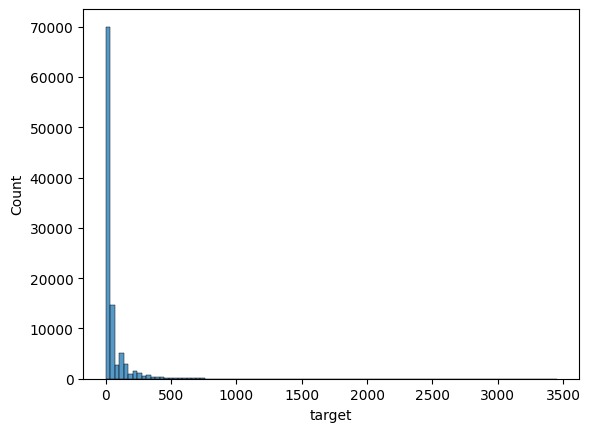

In [21]:
sns.histplot(flights["target"], bins=100)

<Axes: xlabel='target', ylabel='Count'>

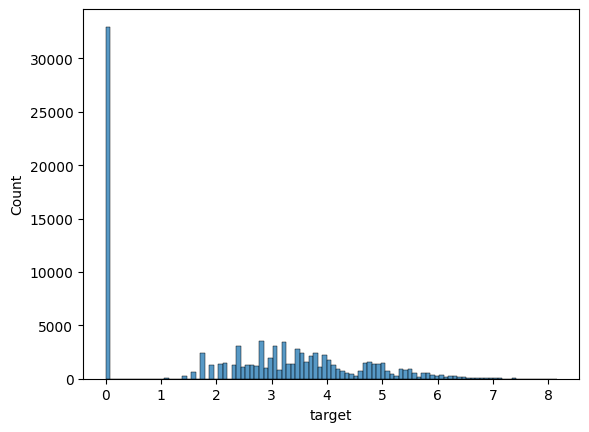

In [22]:
sns.histplot(np.log1p(flights["target"]), bins=100)

<Axes: xlabel='daypart', ylabel='target'>

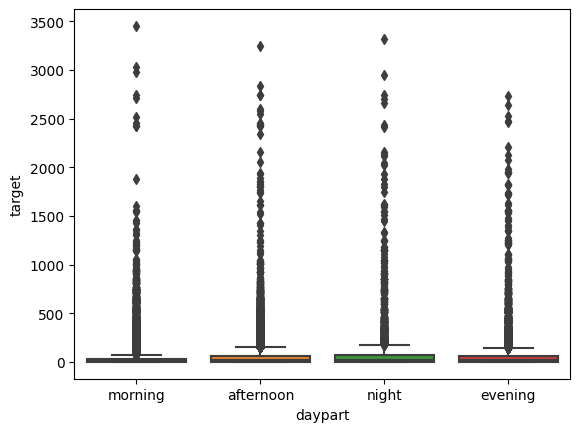

In [23]:
sns.boxplot(x="daypart", y="target", data=flights)

<Axes: xlabel='weekday'>

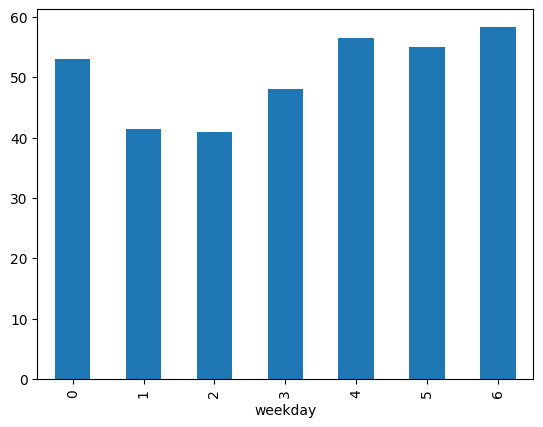

In [24]:
flights.groupby("weekday")["target"].mean().plot(kind="bar")

<Axes: ylabel='od'>

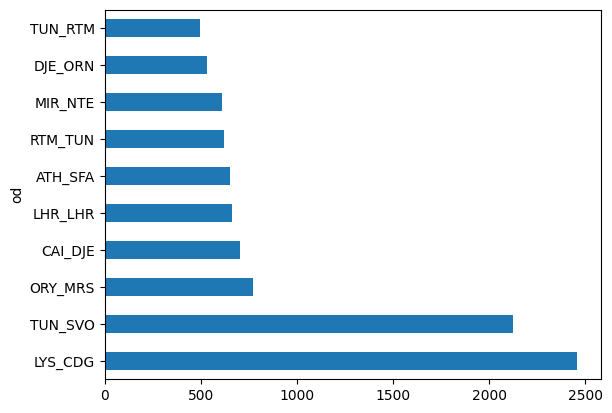

In [25]:
flights.groupby("od")["target"].mean().sort_values(ascending=False).head(10).plot(kind="barh")

<Axes: xlabel='airline', ylabel='target'>

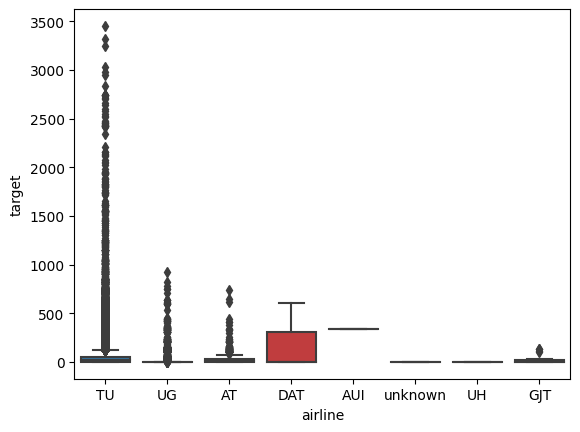

In [26]:
sns.boxplot(x="airline", y="target", data=flights)

<Axes: xlabel='weekofyear'>

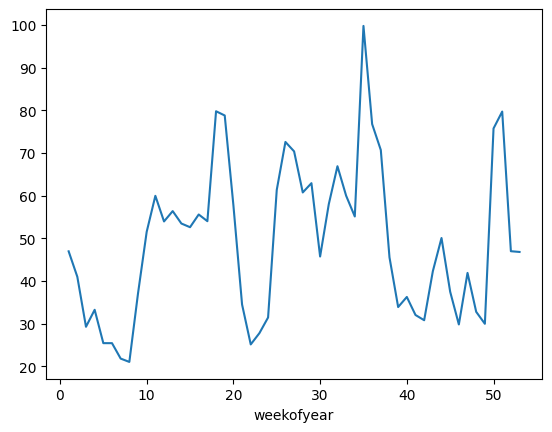

In [27]:
flights.groupby("weekofyear")["target"].mean().plot()

<Axes: xlabel='dep_hour'>

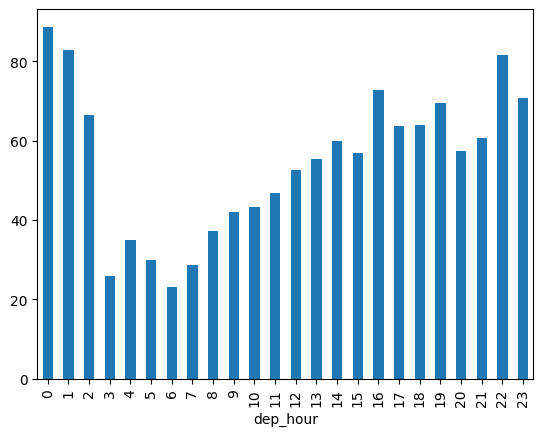

In [28]:
flights.groupby("dep_hour")["target"].mean().plot(kind="bar")

<Axes: xlabel='daypart', ylabel='weekday'>

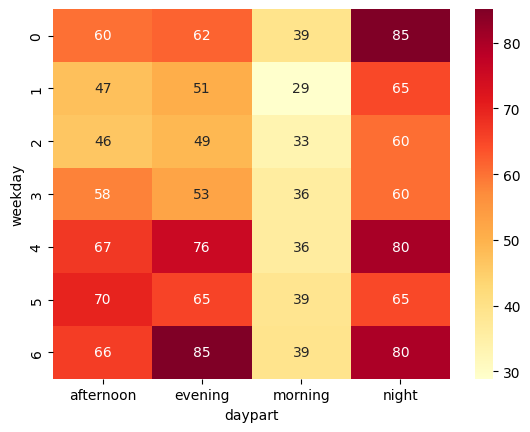

In [29]:
pivot = flights.pivot_table(index="weekday", columns="daypart", values="target", aggfunc="mean")
sns.heatmap(pivot, annot=True, cmap="YlOrRd")


<Axes: xlabel='target', ylabel='flt_type'>

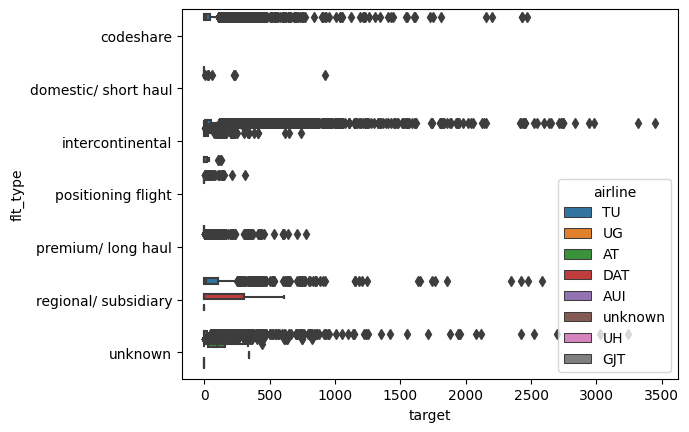

In [30]:
sns.boxplot(y="flt_type", x="target", hue="airline", data=flights)

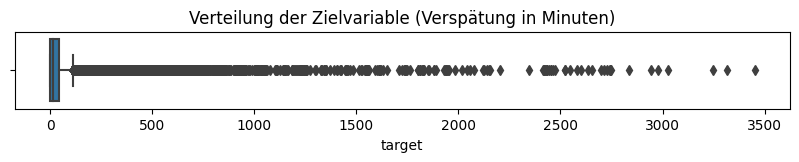

In [31]:
plt.figure(figsize=(10, 1))
sns.boxplot(x=flights["target"])
plt.title("Verteilung der Zielvariable (Verspätung in Minuten)")
plt.show()

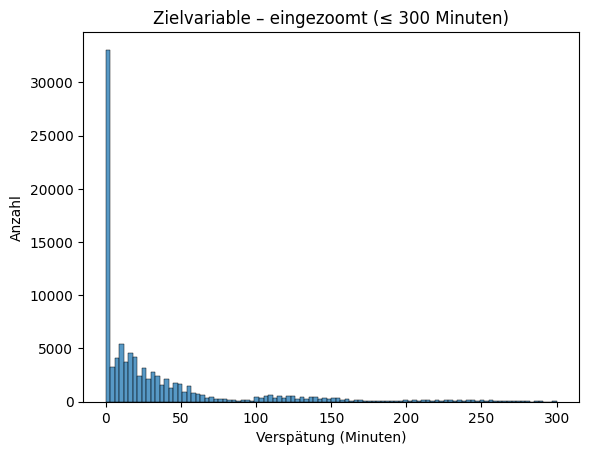

In [32]:
sns.histplot(flights[flights["target"] <= 300]["target"], bins=100)
plt.title("Zielvariable – eingezoomt (≤ 300 Minuten)")
plt.xlabel("Verspätung (Minuten)")
plt.ylabel("Anzahl")
plt.show()

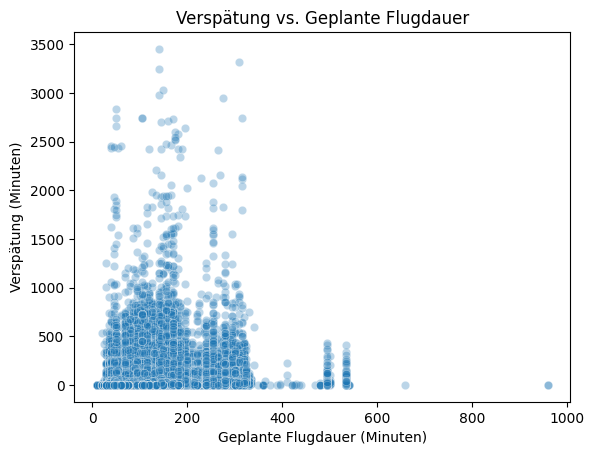

In [33]:
sns.scatterplot(data=flights, x="scheduled_duration_min", y="target", alpha=0.3)
plt.title("Verspätung vs. Geplante Flugdauer")
plt.xlabel("Geplante Flugdauer (Minuten)")
plt.ylabel("Verspätung (Minuten)")
plt.show()


In [103]:
outliers = flights[flights["target"] > 500]
print(f"Anzahl der Flüge mit > 500 Min Verspätung: {len(outliers)}")

Anzahl der Flüge mit > 500 Min Verspätung: 1185


## Baseline Model (Janina)

#### Mean pro Abflughafen (!!!Mean nur auf Train Daten berechnen!!!)

In [35]:
# Ziel: Flüge mit mehr als 15 Minuten Verspätung als "verspätet" markieren
flights["is_delayed"] = (flights["target"] > 15).astype(int)

In [36]:
def baseline_model_mean_delay(flights, test_df, group_col='depstn', target_col='target'):
    """
    Baseline predictor: assigns the mean target value per group_col (e.g. DEPSTN) to each entry in test_df.
    """
    # Calculate mean delay per departure airport from training data
    group_mean = flights.groupby(group_col)[target_col].mean()

    # Predict for test set based on departure airport
    y_pred = test_df[group_col].map(group_mean)
    y_pred.fillna(flights[target_col].mean(), inplace=True)  # if DEPSTN in test but not in train: fill with global mean

    return y_pred

In [37]:
### X und y definieren
X = flights.drop("target", axis=1)
y = flights.target

In [38]:
### Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=RSEED)

In [39]:
# Create predictions
flights_baseline = X_train.copy()
flights_baseline["target"] = y_train
test_df_baseline = X_test.copy()
test_df_baseline["target"] = y_test  # not used for prediction, but keeps interface consistent

y_pred_baseline = baseline_model_mean_delay(flights_baseline, test_df_baseline)

In [102]:
# Evaluate RMSE & R2
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
print(f"R2 Score: {round((r2_score(y_test, y_pred_baseline)),2)}")
print(f"Baseline RMSE: {rmse_baseline:.2f} minutes")

R2 Score: 0.02
Baseline RMSE: 104.84 minutes


## Model Comparison

In [41]:
print(flights["is_delayed"].value_counts())

is_delayed
0    52301
1    50329
Name: count, dtype: int64


In [42]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102630 entries, 0 to 107832
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   datop                   102630 non-null  datetime64[ns]
 1   depstn                  102630 non-null  object        
 2   dep_country             102630 non-null  object        
 3   arrstn                  102630 non-null  object        
 4   arr_country             102630 non-null  object        
 5   std                     102630 non-null  datetime64[ns]
 6   sta                     102630 non-null  datetime64[ns]
 7   status                  102630 non-null  object        
 8   target                  102630 non-null  float64       
 9   od                      102630 non-null  object        
 10  weekday                 102630 non-null  int32         
 11  month                   102630 non-null  int32         
 12  dep_hour                102630 non-

In [43]:
## Features die für Modelle benutzt werden
shared_features = [
    "weekday", "month", "dep_hour", "arr_hour",
    "scheduled_duration_min", "is_weekend",
    "airline", "flt_type", "daypart", "od", "weekofyear"
]

numerical_features = ["weekday", "month", "dep_hour", "arr_hour", "scheduled_duration_min", "is_weekend", "weekofyear"]
categorical_features = ["airline", "flt_type", "daypart", "od"]

In [104]:
## Feature & Zieldefinition
flights["target_capped"] = np.clip(flights["target"], 0, 500)
X = flights[shared_features]
y_class = flights["is_delayed"]
y_reg = flights["target_capped"]

In [105]:
## Train-Test-Split (mit zwei Zielen)
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

In [106]:
## Klassifizierungspipeline

# ColumnTransformer für Preprocessing
class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features)
    ]
)

logreg_pipeline = Pipeline([
    ("preprocessing", class_preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", random_state=RSEED, C=1, penalty="l2"))
])
logreg_pipeline.fit(X_train, y_train_class)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['weekday', 'month',
                                                   'dep_hour', 'arr_hour',
                                                   'scheduled_duration_min',
                                                   'is_weekend',
                                                   'weekofyear']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['airline', 'flt_type',
                                                   'daypart', 'od'])])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='saga'))])

In [99]:
# # 🔍 Parameter-Raum
# param_grid = {
#     'classifier__C': [0.01, 0.1, 1.0, 10.0],
#     'classifier__penalty': ['l2'],
#     'classifier__class_weight': [None, 'balanced'],
#     'classifier__solver': ['lbfgs', 'saga']
# }

# # 🚀 GridSearchCV Setup
# grid_search = GridSearchCV(
#     estimator=logreg_pipeline,
#     param_grid=param_grid,
#     scoring='f1',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# # 🔧 Training starten
# grid_search.fit(X_train_c, y_train_c)

# # ✅ Bestes Modell und Parameter abrufen
# best_model = grid_search.best_estimator_
# best_params = grid_search.best_params_

In [100]:
print(best_params)
print(best_model)

NameError: name 'best_params' is not defined

In [ ]:
# # Wahrscheinlichkeiten aus predict_proba
# y_proba_best = best_model.predict_proba(X_val_c)[:, 1]

# # Verschiedene Schwellen durchtesten
# for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
#     y_pred_thresh = (y_proba_best >= threshold).astype(int)
    
#     precision = precision_score(y_val_c, y_pred_thresh)
#     recall = recall_score(y_val_c, y_pred_thresh)
#     f1 = f1_score(y_val_c, y_pred_thresh)
    
#     print(f"\n--- Schwelle: {threshold} ---")
#     print(f"Precision: {precision:.3f}")
#     print(f"Recall:    {recall:.3f}")
#     print(f"F1-Score:  {f1:.3f}")

In [107]:
# Vorhersagen
y_pred_c = logreg_pipeline.predict(X_test)

# Threshold festlegen
threshold = 0.4

# Wahrscheinlichkeiten holen (Klasse 1)
y_proba_val = logreg_pipeline.predict_proba(X_test)[:, 1]

# Threshold anwenden
y_pred_thresh = (y_proba_val >= threshold).astype(int)


# Evaluation
print("🚀 Klassifikationsbericht für Logistic Regression:")
print(classification_report(y_test_class, y_pred_thresh, digits=3))
print("🧱 Confusion Matrix:")
print(confusion_matrix(y_test_class, y_pred_thresh))

🚀 Klassifikationsbericht für Logistic Regression:
              precision    recall  f1-score   support

           0      0.792     0.440     0.566     10460
           1      0.602     0.880     0.715     10066

    accuracy                          0.656     20526
   macro avg      0.697     0.660     0.640     20526
weighted avg      0.699     0.656     0.639     20526

🧱 Confusion Matrix:
[[4603 5857]
 [1207 8859]]


In [108]:
y_train_log = np.log1p(y_train_reg)

reg_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features)
])

regressor_pipeline = Pipeline([
    ("preprocessing", reg_preprocessor),  # gleiche Spalten + Transformer
    ("regressor", RandomForestRegressor(random_state=42))
])
#regressor_pipeline.fit(X_train[y_train_class == 1], y_train_reg[y_train_class == 1])
regressor_pipeline.fit(X_train, y_train_log)

# Vorhersagen und Bewertung
y_pred_r = regressor_pipeline.predict(X_test)

rmse_r = np.sqrt(mean_squared_error(y_test_reg, y_pred_r))
mae_r = mean_absolute_error(y_test_reg, y_pred_r)
r2_r = r2_score(y_test_reg, y_pred_r)

print("✅ Regressionsergebnisse für verspätete Flüge:")
print(f"RMSE: {rmse_r:.2f} Minuten")
print(f"MAE:  {mae_r:.2f} Minuten")
print(f"R²:   {r2_r:.4f}")


✅ Regressionsergebnisse für verspätete Flüge:
RMSE: 100.16 Minuten
MAE:  46.90 Minuten
R²:   -0.2547


In [109]:
def predict_delay(flights_df, logreg_model, regressor_model, threshold=0.4):
    is_delayed_proba = logreg_model.predict_proba(flights_df)[:, 1]
    is_delayed_pred = (is_delayed_proba >= threshold).astype(int)

    delay_pred = np.zeros(len(flights_df))

    if np.any(is_delayed_pred == 1):
        delayed_indices = np.where(is_delayed_pred == 1)[0]
        delayed_rows = flights_df.iloc[delayed_indices]
        predicted_log_minutes = regressor_model.predict(delayed_rows)
        predicted_minutes = np.expm1(predicted_log_minutes)
        delay_pred[delayed_indices] = predicted_minutes

    return pd.Series(delay_pred, index=flights_df.index)

In [110]:
combined_pred = predict_delay(X_test, logreg_pipeline, regressor_pipeline, threshold=0.4)

rmse = np.sqrt(mean_squared_error(y_test_reg, combined_pred))
mae = mean_absolute_error(y_test_reg, combined_pred)
r2 = r2_score(y_test_reg, combined_pred)

print(f"📊 Kombi-Modell:\nRMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")

📊 Kombi-Modell:
RMSE: 89.40 | MAE: 41.82 | R²: 0.0005


In [94]:
delay_comparison = pd.DataFrame({
    "true_delay": y_test_reg.values,
    "predicted_delay": combined_pred
})

# Ersten Blick drauf werfen
delay_comparison.head()

,true_delay,predicted_delay
38623,0.0,11.287768
18801,20.0,17.540720
71905,27.0,25.988846
45988,0.0,0.000000
42981,0.0,0.000000


In [52]:
delay_comparison_sorted = delay_comparison.sort_values(by="true_delay", ascending=False)

In [53]:
delay_comparison_sorted

,true_delay,predicted_delay
38940,300.0,80.422085
9590,300.0,5.083834
76869,300.0,44.601343
44924,300.0,227.870627
82568,300.0,0.000000
...,...,...
29973,0.0,0.000000
69426,0.0,0.000000
66427,0.0,0.000000
79284,0.0,0.000000


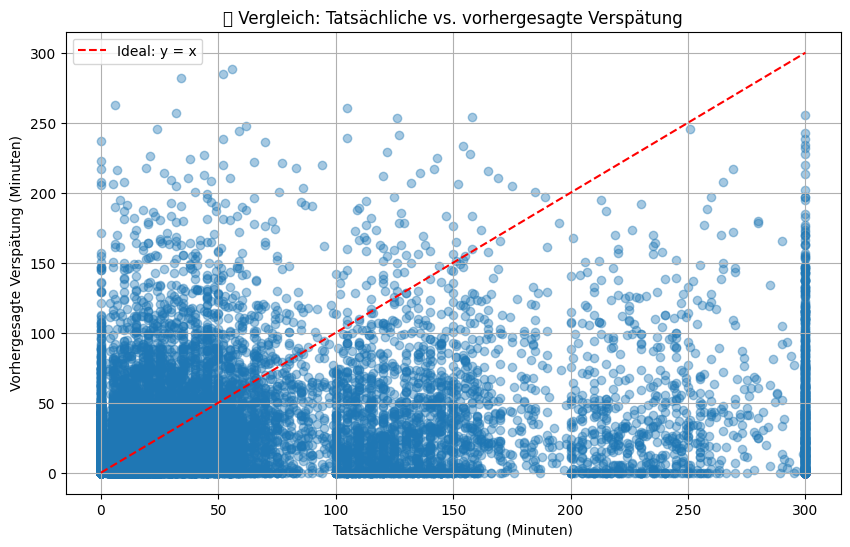

In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(delay_comparison["true_delay"], delay_comparison["predicted_delay"], alpha=0.4)
plt.plot([0, delay_comparison["true_delay"].max()],
         [0, delay_comparison["true_delay"].max()],
         'r--', label="Ideal: y = x")
plt.xlabel("Tatsächliche Verspätung (Minuten)")
plt.ylabel("Vorhergesagte Verspätung (Minuten)")
plt.title("📊 Vergleich: Tatsächliche vs. vorhergesagte Verspätung")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
delay_comparison["abs_error"] = abs(delay_comparison["true_delay"] - delay_comparison["predicted_delay"])
delay_comparison["error"] = delay_comparison["predicted_delay"] - delay_comparison["true_delay"]

# Größte Fehler anzeigen
delay_comparison.sort_values(by="abs_error", ascending=False).head(10)

,true_delay,predicted_delay,abs_error,error
52931,300.0,0.0,300.0,-300.0
34648,300.0,0.0,300.0,-300.0
22767,300.0,0.0,300.0,-300.0
86767,300.0,0.0,300.0,-300.0
52148,300.0,0.0,300.0,-300.0
89448,300.0,0.0,300.0,-300.0
101005,300.0,0.0,300.0,-300.0
79315,300.0,0.0,300.0,-300.0
22041,300.0,0.0,300.0,-300.0
87116,300.0,0.0,300.0,-300.0


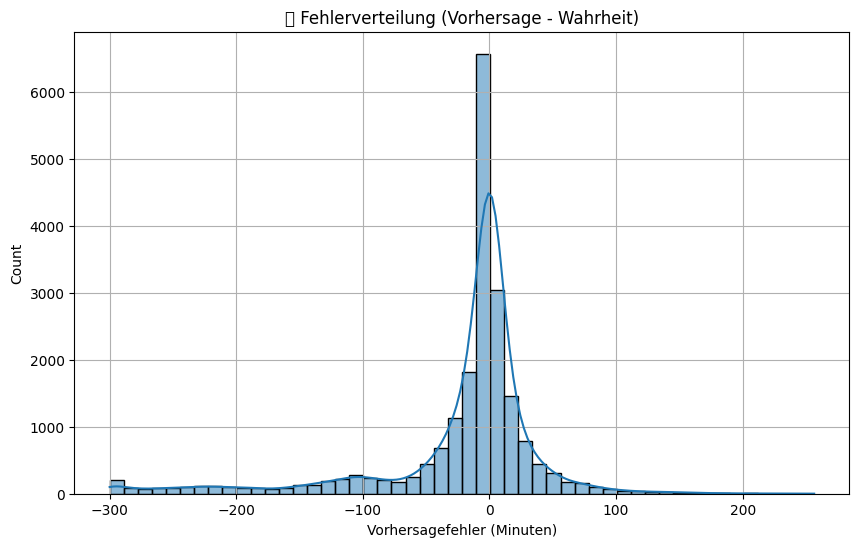

In [61]:
delay_comparison["abs_error"] = abs(delay_comparison["true_delay"] - delay_comparison["predicted_delay"])
delay_comparison["error"] = delay_comparison["predicted_delay"] - delay_comparison["true_delay"]

plt.figure(figsize=(10,6))
sns.histplot(delay_comparison["error"], bins=50, kde=True)
plt.title("📉 Fehlerverteilung (Vorhersage - Wahrheit)")
plt.xlabel("Vorhersagefehler (Minuten)")
plt.grid(True)
plt.show()

In [62]:
from xgboost import XGBRegressor

In [63]:
xgb_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features)
])

In [64]:
xgb_pipeline = Pipeline([
    ("preprocessing", xgb_preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [65]:
y_train_log = np.log1p(y_train_reg)

xgb_pipeline.fit(X_train, y_train_log)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['weekday', 'month',
                                                   'dep_hour', 'arr_hour',
                                                   'scheduled_duration_min',
                                                   'is_weekend',
                                                   'weekofyear']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['airline', 'flt_type',
                                                   'daypart', 'od'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [97]:
combined_pred = predict_delay(X_test, logreg_pipeline, xgb_pipeline, threshold=0.4)

In [96]:
rmse = np.sqrt(mean_squared_error(y_test_reg, combined_pred))
mae = mean_absolute_error(y_test_reg, combined_pred)
r2 = r2_score(y_test_reg, combined_pred)

print("📊 Kombi-Modell mit XGBoost + log-Target:")
print(f"RMSE: {rmse:.2f} Minuten")
print(f"MAE:  {mae:.2f} Minuten")
print(f"R²:   {r2:.4f}")

📊 Kombi-Modell mit XGBoost + log-Target:
RMSE: 73.14 Minuten
MAE:  35.91 Minuten
R²:   -0.0310
